# M1 in simulation — pick one brick out of a flat lego pile

A UR3e with a Robotiq 2F-85 and a wrist RealSense, a plywood table, and a dozen real lego parts lying
flat on it. This notebook is the orchestrator: it stands the cell up and runs the two submodules in
order. Neither of them knows it is in a simulation.

| | |
|---|---|
| [`world.py`](world.py) | the cell — arm, gripper, camera, table, pile. Hardware, no decisions |
| [`submodule_1.py`](submodule_1.py) | look at the pile from two viewpoints, triangulate every brick they agree on, stand over the best one |
| [`submodule_2.py`](submodule_2.py) | descend, close, verify, lift, verify again |

**The perception is the real thing.** The rendered colour and depth go into
`m1.physical.submodule_3.analyse_pile` — the same function, thresholds and scoring that run against the
RealSense on the bench. What the simulator adds is a camera pose that is exactly right and a ground
truth to mark the answer against, which is the one thing the bench cannot provide.

Run the cells in order. Meshcat opens in a browser tab and animates as the arm moves.

In [1]:
import os
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
from pydrake.geometry import Meshcat

SRC_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

from m1.physical import submodule_3 as perception
from m1.simulation import submodule_1, submodule_2
from m1.simulation import world as W


def show(image_bgr, title="", width=13):
    """Draw an OpenCV (BGR) image inline."""
    height = width * image_bgr.shape[0] / image_bgr.shape[1]
    plt.figure(figsize=(width, height))
    plt.imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## 1. Stand up the cell

`Meshcat()` starts a viewer; open the URL it prints in a browser tab and leave it open — everything
below animates there. `build_world` then assembles the arm, bolts the gripper and camera to the
flange, lays the pile out flat and lets it settle.

Change `seed` for a different arrangement of the same parts, or pass `parts=[...]` for different ones
(anything in `lego_3d/urdf/`).

In [2]:
meshcat = Meshcat()
print(f"Open the viewer at: {meshcat.web_url()}")

INFO:drake:Meshcat listening for connections at http://localhost:7000


Open the viewer at: http://localhost:7000


In [3]:
world = W.build_world(meshcat, seed=3)

print(f"{len(world.bricks)} parts on the table:")
for brick, pose in world.brick_poses():
    x, y, z = pose.translation()
    print(f"  {brick.part:34s} at ({x:+.3f}, {y:+.3f}) m, {z * 1000:5.1f} mm up")

2026-08-14 16:02:07.572 | INFO     | m1.simulation.world:build_world:959 - Cell ready: 12 brick(s) flat on the table around (0.30, 0.02) m, gripper opening 2..86 mm, camera 1280x720 at f=931 px.
2026-08-14 16:02:07.572 | INFO     | m1.simulation.world:build_world:965 - Meshcat: http://localhost:7000


12 parts on the table:
  3004__dark_green.urdf              at (+0.332, +0.039) m,   9.6 mm up
  3010__dark_green.urdf              at (+0.282, +0.010) m,   9.6 mm up
  3022__light_bluish_gray.urdf       at (+0.259, +0.053) m,   2.7 mm up
  3021__tan.urdf                     at (+0.248, -0.011) m,   2.0 mm up
  3023__medium_nougat.urdf           at (+0.287, +0.080) m,   3.2 mm up
  3069__white.urdf                   at (+0.341, +0.013) m,   3.2 mm up
  3070__reddish_brown.urdf           at (+0.347, -0.018) m,   3.2 mm up
  3004__tan.urdf                     at (+0.288, -0.025) m,   9.6 mm up
  2431__light_bluish_gray.urdf       at (+0.325, +0.074) m,   3.2 mm up
  3005__dark_bluish_gray.urdf        at (+0.369, +0.007) m,   9.6 mm up
  3024__tan.urdf                     at (+0.227, +0.023) m,   3.2 mm up
  3068__light_bluish_gray.urdf       at (+0.358, +0.039) m,   2.9 mm up


## 2. submodule_1 — find a brick and stand over it

Two viewpoints about 30 cm apart across the pile. Each one is perceived on its own; the brick chosen
is the one both views find, in the same place, with the best mean score. Its position then comes from
triangulating the two lines of sight through its centre, cross-checked against projecting each ray
onto the table plane raised by one brick height.

This is where the physical pipeline's submodule_3 (*which* brick) and submodule_1 (*where* it is, and
go there) become one step.

In [4]:
target, views = submodule_1.run(world)
print()
print("Chosen brick:", target.describe())

2026-08-14 16:02:15.849 | INFO     | m1.simulation.submodule_1:observe:295 - view 1: moving the camera to [ 0.24 -0.13  0.33] m, looking at [0.3  0.02 0.  ] m ...
2026-08-14 16:02:18.900 | INFO     | m1.physical.submodule_3:build_scene:715 - Pile seen from 37 cm, so one millimetre on the table is 2.54 working pixel(s); 94% of the frame has depth.
2026-08-14 16:02:19.608 | INFO     | m1.simulation.submodule_1:observe:304 - view 1: 11 brick(s), 11 graspable, 1 region(s) dropped.
2026-08-14 16:02:19.638 | INFO     | m1.simulation.submodule_1:observe:295 - view 2: moving the camera to [0.24 0.17 0.33] m, looking at [0.3  0.02 0.  ] m ...
2026-08-14 16:02:22.466 | INFO     | m1.physical.submodule_3:build_scene:715 - Pile seen from 37 cm, so one millimetre on the table is 2.50 working pixel(s); 86% of the frame has depth.
2026-08-14 16:02:23.064 | INFO     | m1.simulation.submodule_1:observe:304 - view 2: 11 brick(s), 11 graspable, 1 region(s) dropped.
2026-08-14 16:02:23.065 | INFO     | m1


Chosen brick: dark_green 7.5 x 31.3 x 9.5 mm at (0.2816, 0.0099) m, top face z=0.0095 m, jaws close along 64 deg


### What each view saw

Every brick the perception found is outlined; the five it would send the arm at are numbered in
priority order with the jaw direction drawn across them. The same picture the physical pipeline writes
to `--debug-dir` on the bench.

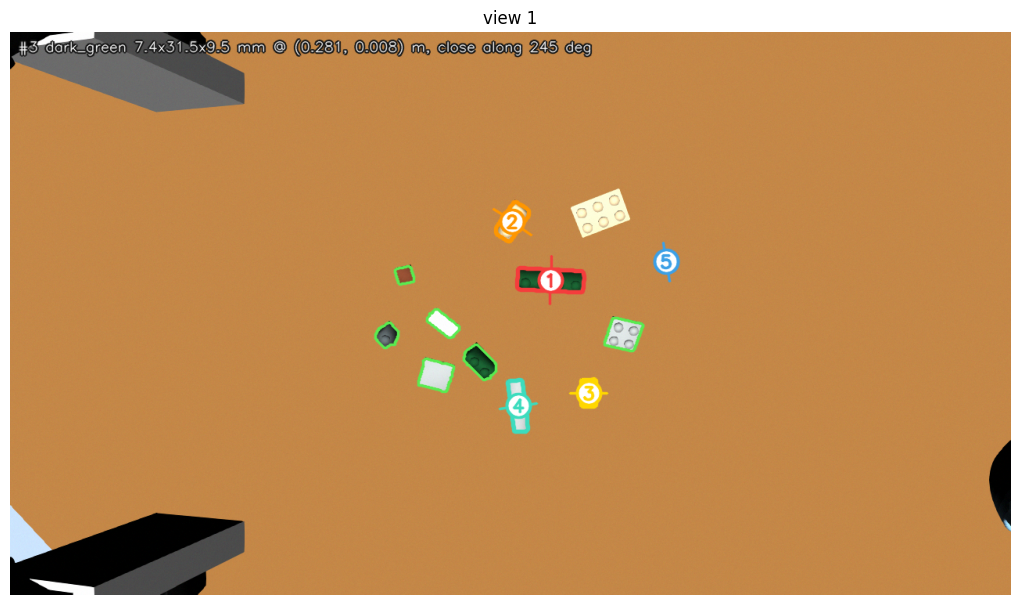

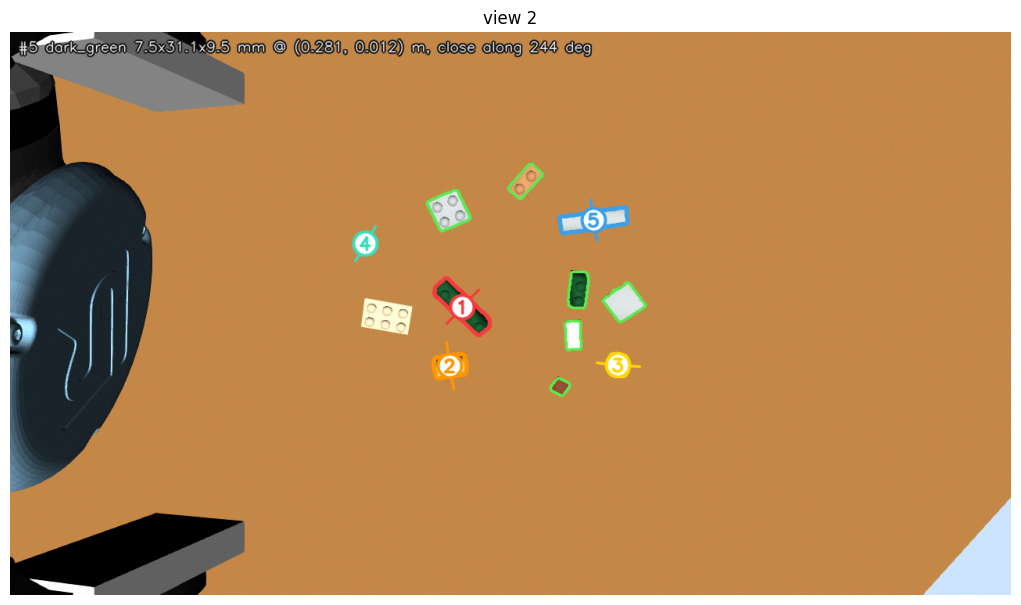

In [5]:
for view in views:
    show(perception.render_overlay(view.analysis), view.name)

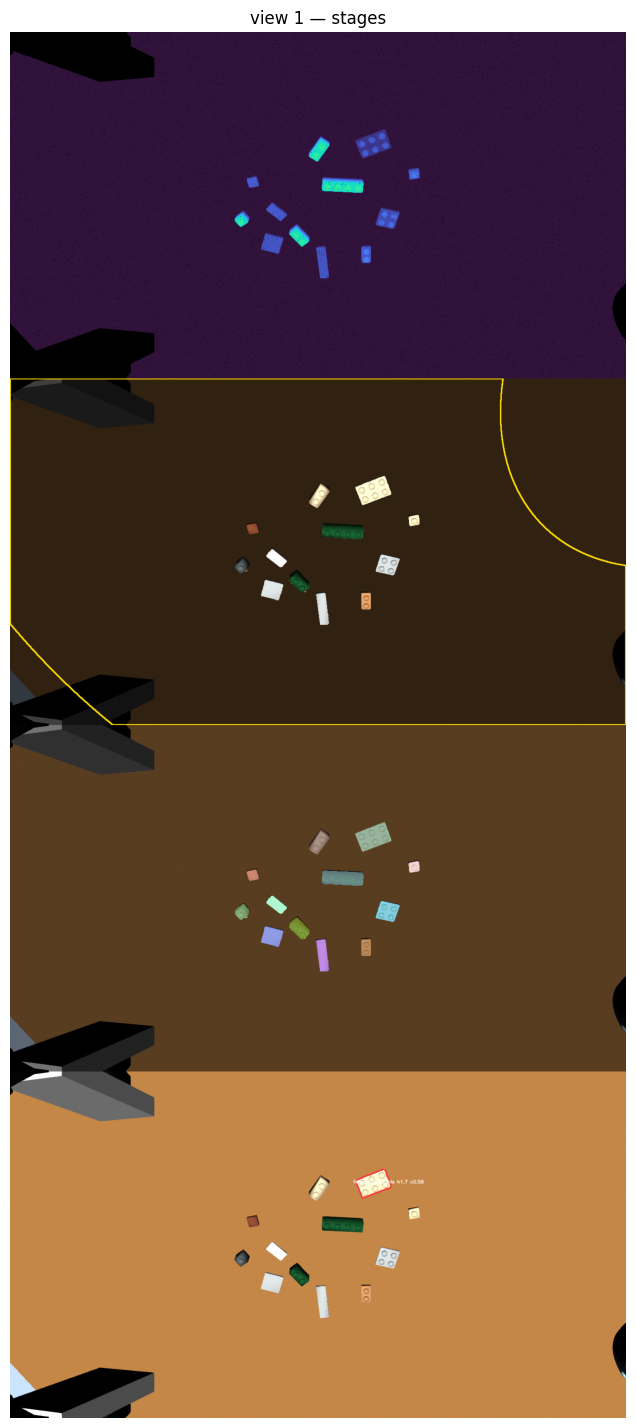

In [6]:
# The stage-by-stage panel for the first view: height above the table, the foreground the hysteresis
# admitted, the instance labels, and the regions that were dropped with the reason why.
show(perception.render_debug_panel(views[0].analysis), f"{views[0].name} — stages", width=8)

### Marking the homework

Nothing above consulted the simulator's ground truth. Now we can: how far is the perceived brick from
the real one, and is it even the right part?

In [6]:
truth = submodule_1.score_against_truth(world, target)

print("how the position was arrived at")
print(f"  triangulated       {np.round(target.triangulated, 4)} m")
print(f"  ray-plane          {np.round(target.plane_projected, 4)} m")
print(f"  lines of sight miss each other by {target.triangulation_gap * 1000:.2f} mm")
print(f"  the two methods differ across the table by {target.method_disagreement * 1000:.2f} mm")
print(f"  used: {target.position_source}")
print()
print("against ground truth")
for key in ("part", "position_error_mm", "height_error_mm", "heading_error_deg"):
    print(f"  {key:20s} {truth[key]}")
print(f"  footprint            {truth['measured_footprint_mm']} mm measured vs {truth['true_footprint_mm']} mm real")

2026-08-14 16:02:40.555 | INFO     | m1.simulation.submodule_1:score_against_truth:1059 - Ground truth: the nearest real brick is 3010__dark_green.urdf, 0.2 mm from where the perception put it; its long axis is 3.7 deg off, and its footprint is [8.0, 32.0] mm against the measured [7.5, 31.3] mm.


how the position was arrived at
  triangulated       [0.2816 0.0099 0.0049] m
  ray-plane          [0.281  0.01   0.0095] m
  lines of sight miss each other by 0.47 mm
  the two methods differ across the table by 0.63 mm
  used: triangulation

against ground truth
  part                 3010__dark_green.urdf
  position_error_mm    0.16
  height_error_mm      -0.05
  heading_error_deg    -3.7
  footprint            [7.5, 31.3] mm measured vs [8.0, 32.0] mm real


## 3. submodule_2 — grasp it and lift it

Descend the capped distance below the brick's top face, close to a width inside the brick so the pads
stall on it, check, lift, and check again after a pause. Both checks read the same signal the real
Robotiq gives: how far the fingers got compared to how far they were told to go.

In [7]:
result = submodule_2.run(world, target)
print()
print(result.describe())

2026-08-14 16:02:44.733 | INFO     | m1.simulation.submodule_2:resolve_grasp_depth:128 - Descending 3.0 mm into the part's 9.5 mm, leaving 6.5 mm of fingertip clearance above the table.
2026-08-14 16:02:44.785 | INFO     | m1.simulation.submodule_2:run:236 - Descending 3.0 mm onto the brick, jaws open at 21.5 mm ...
2026-08-14 16:02:46.326 | INFO     | m1.simulation.submodule_2:run:240 - Closing: commanding 4.5 mm on a 7.5 mm brick ...
2026-08-14 16:02:47.374 | INFO     | m1.simulation.submodule_2:run:259 - Closed on the brick: holding a 7.9 mm object (the brick measured 7.5 mm). Lifting 12 cm ...
2026-08-14 16:02:50.501 | SUCCESS  | m1.simulation.submodule_2:run:286 - grasped and holding: holding a 7.9 mm object (the brick measured 7.5 mm). Descended 3.0 mm, commanded 4.5 mm, pads stopped at 7.9 mm then 7.9 mm after a 12 cm lift, the brick rose 108 mm



grasped and holding: holding a 7.9 mm object (the brick measured 7.5 mm). Descended 3.0 mm, commanded 4.5 mm, pads stopped at 7.9 mm then 7.9 mm after a 12 cm lift, the brick rose 108 mm


In [8]:
if result.success:
    submodule_2.place(world, target)
submodule_2.park(world)

2026-08-14 16:02:53.407 | INFO     | m1.simulation.submodule_2:place:325 - Carrying the brick to [ 0.16 -0.2   0.06] m and releasing it.
2026-08-14 16:02:57.254 | INFO     | m1.simulation.submodule_2:park:306 - Returning to the home configuration with the brick.
2026-08-14 16:02:59.020 | INFO     | m1.simulation.submodule_2:park:306 - Returning to the home configuration with the brick.


## 4. Emptying the pile — one survey, many picks

Two viewpoints cost four seconds of arm travel and two full pile analyses, and up to here that price
has been paid per *brick*. But the two looks see the whole pile, not one brick of it — so
`submodule_1.survey` triangulates **every** brick they agree on, and `PileSession` serves the picks
out of that map without moving the camera again.

The pile is looked at again only when the map runs low. That is also the moment the bricks that were
buried at the start have become the ones on top, so the occluded ones get their triangulation exactly
when it is worth doing — and that repeats until nothing graspable is left.

The price of a cached position is that the pile moves under it. So every pick drops the queued bricks
close enough to the jaws to have been nudged, and a grasp that fails on a position measured *before*
the last pick is remeasured at the next survey rather than written off — while one that fails on a
freshly surveyed position is the brick's own fault, and is left alone for good.

In [9]:
session = submodule_1.PileSession(world)
pile_map = session.look()  # the two looks — and a triangulated position for every brick in them

print(f"\n{pile_map.remaining} brick(s) triangulated in one pair of looks:\n")
print(f"{'#':>2} {'colour':10s} {'w x l mm':>13s} {'position m':>18s} {'score':>6s} {'ray gap':>8s} {'err':>8s}  source")
for rank, brick in enumerate(pile_map.targets, start=1):
    truth = submodule_1.score_against_truth(world, brick)
    print(
        f"{rank:2d} {brick.colour:10s} {brick.width * 1000:5.1f} x {brick.length * 1000:5.1f} "
        f"({brick.position[0]:+.4f}, {brick.position[1]:+.4f}) {brick.score:6.3f} "
        f"{brick.triangulation_gap * 1000:6.2f}mm {truth.get('position_error_mm', float('nan')):6.2f}mm  "
        f"{brick.position_source}"
    )

2026-08-14 16:03:01.666 | INFO     | m1.simulation.submodule_1:observe:295 - view 1: moving the camera to [ 0.24 -0.13  0.33] m, looking at [0.3  0.02 0.  ] m ...
2026-08-14 16:03:04.452 | INFO     | m1.physical.submodule_3:build_scene:715 - Pile seen from 37 cm, so one millimetre on the table is 2.54 working pixel(s); 94% of the frame has depth.
2026-08-14 16:03:05.032 | INFO     | m1.simulation.submodule_1:observe:304 - view 1: 10 brick(s), 10 graspable, 1 region(s) dropped.
2026-08-14 16:03:05.059 | INFO     | m1.simulation.submodule_1:observe:295 - view 2: moving the camera to [0.24 0.17 0.33] m, looking at [0.3  0.02 0.  ] m ...
2026-08-14 16:03:07.871 | INFO     | m1.physical.submodule_3:build_scene:715 - Pile seen from 37 cm, so one millimetre on the table is 2.50 working pixel(s); 86% of the frame has depth.
2026-08-14 16:03:08.469 | INFO     | m1.simulation.submodule_1:observe:304 - view 2: 11 brick(s), 11 graspable, 1 region(s) dropped.
2026-08-14 16:03:08.471 | SUCCESS  | m1


9 brick(s) triangulated in one pair of looks:

 # colour          w x l mm         position m  score  ray gap      err  source
 1 tan          7.7 x  15.5 (+0.2874, -0.0254)  1.217   0.52mm   0.19mm  triangulation
 2 dark_green   8.0 x   8.1 (+0.3691, +0.0070)  1.086   0.53mm   0.29mm  triangulation
 3 dark_tan     8.0 x  15.3 (+0.2874, +0.0796)  1.078   0.04mm   0.04mm  triangulation
 4 white        7.4 x   7.8 (+0.2269, +0.0232)  1.074   0.29mm   0.16mm  triangulation
 5 white       15.6 x  15.7 (+0.2589, +0.0534)  1.065   0.16mm   0.08mm  triangulation
 6 reddish_brown   7.5 x   7.7 (+0.3473, -0.0185)  1.021   0.39mm   0.27mm  triangulation
 7 white        7.9 x  15.6 (+0.3412, +0.0130)  0.983   0.45mm   0.28mm  triangulation
 8 dark_green   8.7 x  15.4 (+0.3322, +0.0391)  0.975   0.35mm   0.08mm  triangulation
 9 white       16.2 x  16.7 (+0.3577, +0.0395)  0.889   0.47mm   0.16mm  triangulation


In [ ]:
MAX_ATTEMPTS = 40  # a runaway guard, not a plan: the loop is meant to end when the pile does

picks = []
while (target := session.next_target()) is not None:
    print(
        f"\n{'=' * 78}\npick {len(picks) + 1} — from survey {target.survey_round}, "
        f"{session.map.remaining} brick(s) still queued\n{'=' * 78}"
    )
    # Marked before the grasp, not after. Once the brick has been carried off to the corner, the
    # nearest real brick to where it used to be is one of its neighbours, and the error is nonsense.
    truth = submodule_1.score_against_truth(world, target)
    result = submodule_2.run(world, target)
    if result.success:
        submodule_2.place(world, target)
    session.record(target, result.success)
    picks.append((target, result, truth))
    if len(picks) >= MAX_ATTEMPTS:
        print("Hit the attempt guard; stopping.")
        break

submodule_2.park(world)

2026-08-14 16:03:21.224 | INFO     | m1.simulation.submodule_1:go_to_pregrasp:706 - Jaws opened to 21.7 mm for a 7.7 mm brick.
2026-08-14 16:03:21.288 | INFO     | m1.simulation.submodule_1:go_to_pregrasp:733 - Retracting to the home configuration before crossing the table ...
2026-08-14 16:03:23.073 | INFO     | m1.simulation.submodule_1:go_to_pregrasp:735 - Swinging over the brick at 12 cm, jaws already square to its long axis, then straight down to the pregrasp 3 cm above its top face ...
2026-08-14 16:03:27.858 | SUCCESS  | m1.simulation.submodule_1:go_to_pregrasp:757 - At the pregrasp: fingertips at [ 0.2841 -0.0257  0.041 ] m, 3.6 mm from commanded.
2026-08-14 16:03:27.858 | INFO     | m1.simulation.submodule_1:_take_reachable:980 - Pick 1 from survey 1 (8 triangulated brick(s) still queued, no camera move needed).
2026-08-14 16:03:27.859 | INFO     | m1.simulation.submodule_1:score_against_truth:1059 - Ground truth: the nearest real brick is 3004__tan.urdf, 0.3 mm from where the


pick 1 — from survey 1, 8 brick(s) still queued


2026-08-14 16:03:29.392 | INFO     | m1.simulation.submodule_2:run:240 - Closing: commanding 4.7 mm on a 7.7 mm brick ...
2026-08-14 16:03:30.439 | INFO     | m1.simulation.submodule_2:run:259 - Closed on the brick: holding a 7.4 mm object (the brick measured 7.7 mm). Lifting 12 cm ...
2026-08-14 16:03:33.559 | SUCCESS  | m1.simulation.submodule_2:run:286 - grasped and holding: holding a 7.9 mm object (the brick measured 7.7 mm). Descended 3.0 mm, commanded 4.7 mm, pads stopped at 7.4 mm then 7.9 mm after a 12 cm lift, the brick rose 110 mm
2026-08-14 16:03:33.587 | INFO     | m1.simulation.submodule_2:place:325 - Carrying the brick to [ 0.16 -0.2   0.06] m and releasing it.
2026-08-14 16:03:37.399 | INFO     | m1.simulation.submodule_2:park:306 - Returning to the home configuration with the brick.
2026-08-14 16:03:39.750 | INFO     | m1.simulation.submodule_1:go_to_pregrasp:706 - Jaws opened to 22.0 mm for a 8.0 mm brick.
2026-08-14 16:03:39.829 | INFO     | m1.simulation.submodule_1:


pick 2 — from survey 1, 7 brick(s) still queued


2026-08-14 16:03:47.920 | INFO     | m1.simulation.submodule_2:run:240 - Closing: commanding 5.0 mm on a 8.0 mm brick ...
2026-08-14 16:03:48.955 | INFO     | m1.simulation.submodule_2:run:259 - Closed on the brick: holding a 7.9 mm object (the brick measured 8.0 mm). Lifting 12 cm ...
2026-08-14 16:03:52.149 | SUCCESS  | m1.simulation.submodule_2:run:286 - grasped and holding: holding a 7.9 mm object (the brick measured 8.0 mm). Descended 3.0 mm, commanded 5.0 mm, pads stopped at 7.9 mm then 7.9 mm after a 12 cm lift, the brick rose 117 mm
2026-08-14 16:03:52.173 | INFO     | m1.simulation.submodule_2:place:325 - Carrying the brick to [ 0.16 -0.2   0.06] m and releasing it.
2026-08-14 16:03:56.084 | INFO     | m1.simulation.submodule_2:park:306 - Returning to the home configuration with the brick.
2026-08-14 16:03:58.438 | INFO     | m1.simulation.submodule_1:go_to_pregrasp:706 - Jaws opened to 22.0 mm for a 8.0 mm brick.
2026-08-14 16:03:58.503 | INFO     | m1.simulation.submodule_1:

...

2026-08-14 16:06:59.047 | INFO     | m1.simulation.submodule_2:run:240 - Closing: commanding 4.5 mm on a 7.5 mm brick ...
2026-08-14 16:07:00.094 | ERROR    | m1.simulation.submodule_2:run:246 - The grasp did not take at the table: the pads reached 4.3 mm, the width they were commanded to -- nothing between them
2026-08-14 16:07:00.094 | INFO     | m1.simulation.submodule_2:_release_and_retreat:298 - Opening the jaws and retreating to the pregrasp.
2026-08-14 16:07:02.276 | INFO     | m1.simulation.submodule_1:record:918 - The grasp failed on a position measured before the pile was last reached into; it will be remeasured at the next survey rather than written off.
2026-08-14 16:07:02.277 | INFO     | m1.simulation.submodule_1:_survey:946 - Re-surveying: 1 triangulated brick(s) left, below the 2 threshold. Bricks that were occluded at the start get located now.
2026-08-14 16:07:02.303 | INFO     | m1.simulation.submodule_1:observe:295 - view 1: moving the camera to [ 0.24 -0.13  0.33] 


pick 15 — from survey 4, 2 brick(s) still queued


2026-08-14 16:07:18.585 | INFO     | m1.simulation.submodule_2:run:240 - Closing: commanding 4.6 mm on a 7.6 mm brick ...
2026-08-14 16:07:19.695 | ERROR    | m1.simulation.submodule_2:run:246 - The grasp did not take at the table: the pads reached 4.4 mm, the width they were commanded to -- nothing between them
2026-08-14 16:07:19.695 | INFO     | m1.simulation.submodule_2:_release_and_retreat:298 - Opening the jaws and retreating to the pregrasp.
2026-08-14 16:07:21.829 | INFO     | m1.simulation.submodule_1:record:915 - The grasp failed on a freshly surveyed position; leaving that brick alone from now on.
2026-08-14 16:07:22.433 | INFO     | m1.simulation.submodule_1:go_to_pregrasp:706 - Jaws opened to 21.6 mm for a 7.6 mm brick.
2026-08-14 16:07:22.501 | INFO     | m1.simulation.submodule_1:go_to_pregrasp:733 - Retracting to the home configuration before crossing the table ...
2026-08-14 16:07:24.390 | INFO     | m1.simulation.submodule_1:go_to_pregrasp:735 - Swinging over the bric


pick 16 — from survey 4, 1 brick(s) still queued


2026-08-14 16:07:31.424 | INFO     | m1.simulation.submodule_2:run:240 - Closing: commanding 4.6 mm on a 7.6 mm brick ...
2026-08-14 16:07:32.545 | ERROR    | m1.simulation.submodule_2:run:246 - The grasp did not take at the table: the pads reached 4.4 mm, the width they were commanded to -- nothing between them
2026-08-14 16:07:32.545 | INFO     | m1.simulation.submodule_2:_release_and_retreat:298 - Opening the jaws and retreating to the pregrasp.
2026-08-14 16:07:34.646 | INFO     | m1.simulation.submodule_1:record:918 - The grasp failed on a position measured before the pile was last reached into; it will be remeasured at the next survey rather than written off.
2026-08-14 16:07:34.647 | INFO     | m1.simulation.submodule_1:_survey:946 - Re-surveying: 1 triangulated brick(s) left, below the 2 threshold. Bricks that were occluded at the start get located now.
2026-08-14 16:07:34.671 | INFO     | m1.simulation.submodule_1:observe:295 - view 1: moving the camera to [ 0.24 -0.13  0.33] 

In [ ]:
print(f"{'part':30s} {'grasped':>8s} {'pos err':>9s} {'survey':>7s} {'width':>14s}  reason")
for target, result, truth in picks:
    print(
        f"{str(result.part):30s} {'yes' if result.success else 'NO':>8s} "
        f"{truth.get('position_error_mm', float('nan')):8.2f}mm {target.survey_round:7d} "
        f"{target.width * 1000:5.1f}->{result.width_after_lift * 1000:5.1f}mm  {result.reason}"
    )

stats = session.summary()
successes = sum(1 for _, result, _ in picks if result.success)
saved = 1 - stats["camera_moves"] / max(stats["camera_moves_one_survey_per_pick"], 1)
print(f"\n{successes}/{len(picks)} picked, {world.elapsed:.0f} s of simulated time.")
print(
    f"{stats['surveys']} survey(s) for {stats['attempts']} pick(s): {stats['camera_moves']} camera moves "
    f"instead of the {stats['camera_moves_one_survey_per_pick']} a look-every-time loop would take "
    f"— {saved:.0%} of the looking saved."
)
if stats["given_up_on"]:
    print(f"{stats['given_up_on']} brick(s) refused a freshly surveyed grasp and were left where they are.")

## Knobs worth turning

| where | what |
|---|---|
| `W.DEFAULT_PILE_PARTS`, `build_world(seed=...)` | which parts are in the pile and how they land |
| `W.PILE_CENTER`, `W.PILE_RADIUS` | how tightly packed the pile is — tighter means less fingertip room, which is what the grasp scoring is about |
| `W.RGB_NOISE_COUNTS`, `W.DEPTH_NOISE_M`, `W.DEPTH_DROPOUT_FRACTION` | how good the camera is. Turning the depth noise up is the honest way to see how much of the pipeline is leaning on it |
| `submodule_1.VIEWPOINTS` | where the two looks are taken from. Move them closer together and watch the triangulation gap grow |
| `submodule_1.RESURVEY_WHEN_REMAINING_BELOW` | how much of each survey to spend before looking again. 1 squeezes every brick out of a map; raising it trades cycle time for fresher positions |
| `submodule_1.FINGER_DISTURBANCE_MARGIN_M` | how far past the open jaws a queued brick is assumed to have been nudged, and so re-triangulated rather than trusted |
| `submodule_1.MAX_CONSECUTIVE_FAILURES` | how many failed grasps in a row before the map is thrown away regardless of what it still has queued |
| `perception.SCORE_WEIGHTS`, `perception.PRIORITY_MIN_CONFIDENCE` | what makes one brick a better grasp than another |
| `submodule_2.GRASP_DEPTH_M`, `GRIPPER_SQUEEZE_M` | how far down the brick's side the pads go, and how hard they pinch |